In [40]:
from numpy.random.mtrand import random_sample

bream_length = [ 25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7,
                 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5,
                 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0,
                 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [ 242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0,
                 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0,
                 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0,
                 925.0, 975.0, 950.0]

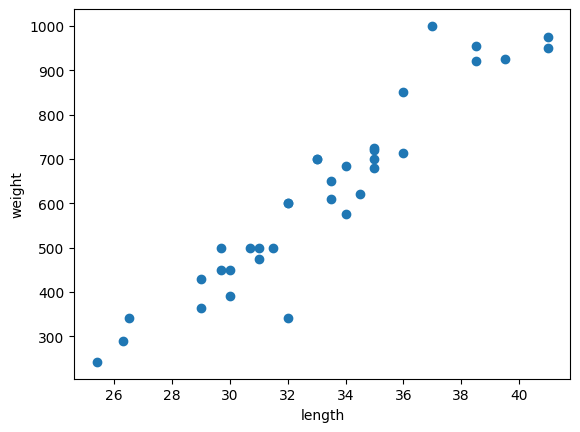

In [41]:
import matplotlib.pyplot as plt

# scatter() 함수: 산점도 그림
plt.scatter(bream_length, bream_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

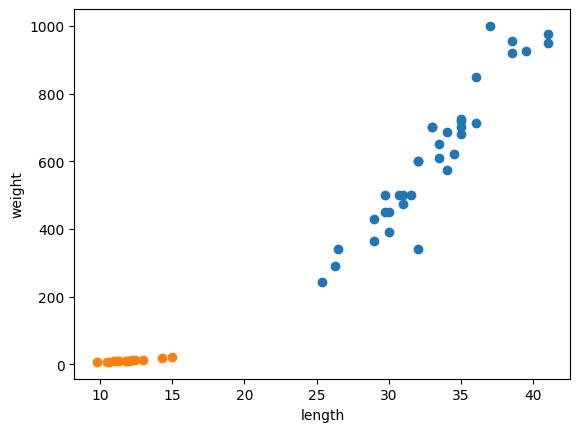

In [42]:
smelt_length = [ 9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2,
                 12.4, 13.0, 14.3, 15.0]
smelt_weight = [ 6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4,
                 12.2, 19.7, 19.9]

# scatter() 함수: 산점도 그림
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- 첫 번째 머신러닝 프로그램
    - k-최근접 이웃 알고리즘 사용해 도미 & 빙어 데이터 구분
        - k-최근접 이웃 알고리즘 사용 전 앞에서 준비했던 도미 & 빙어 데이터를 하나의 데이터로 합침

In [43]:
# 데이터 병합
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

# length와 weight 리스트를 2차원 리스트로 만들기
fish_data = [[l, w] for l, w in zip(length, weight)]
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


In [44]:
# 정답 데이터 준비
# 도미=1, 빙어=0

fish_target = [1] * 35 + [0] * 14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [45]:
# 사이킷런 패키지에서 k-최근접 이웃 알고리즘 주현한 클래스인 KNeighborsClassifier 임포트
from sklearn.neighbors import KNeighborsClassifier

# 임포트한 KNeighborsClassifier 클래스의 객체 만들기
kn = KNeighborsClassifier()

# 훈련
kn.fit(fish_data, fish_target)

# 평가
kn.score(fish_data, fish_target)

1.0

- KNeigborsClassifier (K-최근접 이웃 알고리즘, KNN)
    - 핵심 아이디어: 비슷한 데이터는 비슷한 그룹에 속할 가능성 높음
    - K: 참고할 이웃 개수
    - Distance: 데이터 간 거리
        - 유클리드 거리: $\sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$
            - 직선 거리, 실제 공간에서 거리 개념과 비슷한 의미 가질 때 사용
        - 맨해튼 거리: $D = |x_1 - x_2| + |y_1 - y_2|$
            - 격자 형태 거리, 고차원 데이터, feature 많고 feature 간 독립성 강할 때 사용

In [46]:
# 예측
kn.predict([[30, 600]])

array([1])

In [47]:
# k의 값 변경 가능
# k=49로 테스트
kn49 = KNeighborsClassifier(n_neighbors=49)

kn49.fit(fish_data, fish_target)
kn49_score = kn49.score(fish_data, fish_target)

# fish_data에 있는 생선 중 도미 35개, 빙어 14개
print("35/49:", 35/49)
print("kn49 score:", kn49_score)

35/49: 0.7142857142857143
kn49 score: 0.7142857142857143


- 훈련 세트와 데이터 세트
    - 두 파이썬 리스트 순회하며 각 생선 길이 & 무게를 하나의 리스트로 담은 2차원 리스트 생성

In [48]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [49]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target = [1]*35 + [0] *14

In [50]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

print(fish_data[0:5])

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0]]


In [51]:
# 훈련 세트로 입력값 중 0부터 34번째 인덱스까지 사용
train_input = fish_data[:35]

# 훈련 세트로 타깃값 중 0부터 334번째 인덱스까지 사용
train_target = fish_target[:35]

# 테스트 세트로 입력값 중 35번째부터 마지막 인덱스까지 사용
test_input = fish_data[35:]

# 테스트 세트로 타깃값 중 35번째부터 마지막 인덱스까지 사용
test_target = fish_target[35:]

In [52]:
kn = kn.fit(train_input, train_target)
kn.score(test_input, test_target)

# 도미 데이터로만 훈련 -> 샘플링 편향 발생 -> 정확도 0.0 나옴

0.0

- 샘플링 편향(sampling bisa)
    - 훈련 세트 & 테스트 세트에 샘플이 골고루 섞여 있지 않아 샘플링이 한쪽으로 치우침

In [53]:
import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

print(input_arr)
print(input_arr.shape)      # (샘플 수, 특성 수)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]
(49, 2)


In [54]:
# 인덱스 섞기

np.random.seed(42)
index = np.arange(49)       # 0 ~ n-1까지 1씩 증가하는 배열 생성
np.random.shuffle(index)    # 무작위 셔플

print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [55]:
print(input_arr[[1, 3]])

[[ 26.3 290. ]
 [ 29.  363. ]]


In [56]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

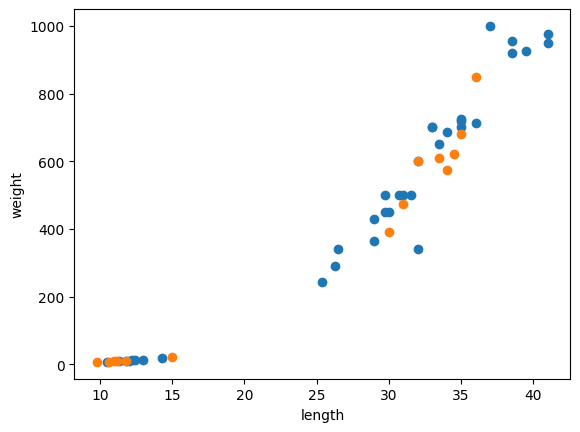

In [57]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(test_input[:, 0], test_input[:, 1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [58]:
kn = kn.fit(train_input, train_target)
print(kn.score(test_input, test_target))
print(kn.predict(test_input))          # 테스트 세트의 예측 결과 & 실제 타깃 확인
print(test_target)

1.0
[0 0 1 0 1 1 1 0 1 1 0 1 1 0]
[0 0 1 0 1 1 1 0 1 1 0 1 1 0]


In [59]:
# column_stack() 함수: 전달받은 리스트를 일렬로 세워 차례대로 나란히 연결
fish_data = np.column_stack((fish_length, fish_weight))
print(fish_data[:5])

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


In [60]:
# 넘파이로 데이터 준비

fish_target = np.concatenate((np.ones(35), np.zeros(14)))
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [61]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42
)

In [62]:
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

print(test_target)      # 도미와 빙어의 비율로 인해 샘플링 편향이 다소 나타남

(36, 2) (13, 2)
(36,) (13,)
[1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [63]:
# 훈련 세트 & 테스트 세트에 샘플의 클래스 비율 일전X 시 모델이 일부 샘플 올바르게 학습 불가능
# train_test_split() 함수 이용해 해결
    # stratify 매개변수에 타깃 데이터 전달 -> 클래스 비율에 맞게 데이터 나눔
    # 훈련 데이터 작음 / 특정 클래스 샘플 개수 적을 때 유용

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, stratify=fish_target, random_state=42
)
print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [64]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
print(kn.score(test_input, test_target))
print(kn.predict([[25, 150]]))      # 다른 도미 데이터 넣고 확인(25cm, 150g)

1.0
[0.]


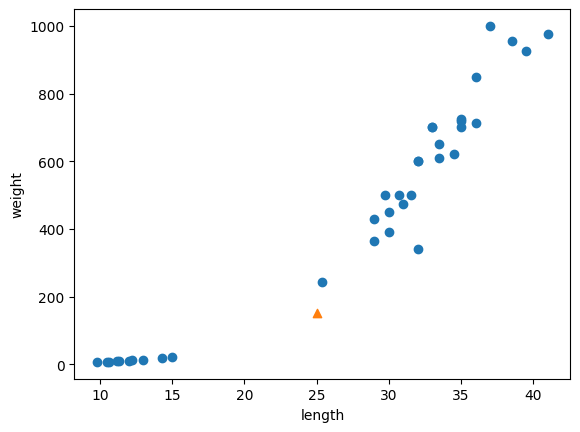

In [65]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

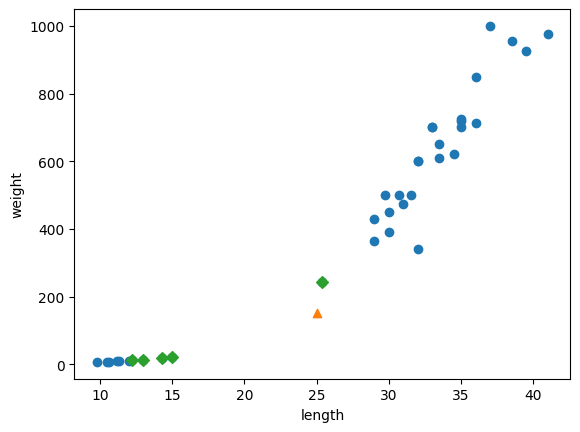

In [66]:
distances, indexes = kn.kneighbors([[25, 150]])        # 이웃까지의 거리와 이웃 샘플의 인덱스 반환

# 삼각형 샘플에 가장 가까운 5개의 샘플이 초록 다이아몬드로 표시
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes, 0],
            train_input[indexes, 1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [67]:
# 삼각형 샘플에 이웃한 데이터 확인
print(train_input[indexes])

# 타깃 데이터로 확인
print(train_target[indexes])

# kneighbors() 메서드에서 반환한 distances 배열(이웃 샘플까지의 거리) 출력
print(distances)

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]
[[1. 0. 0. 0. 0.]]
[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


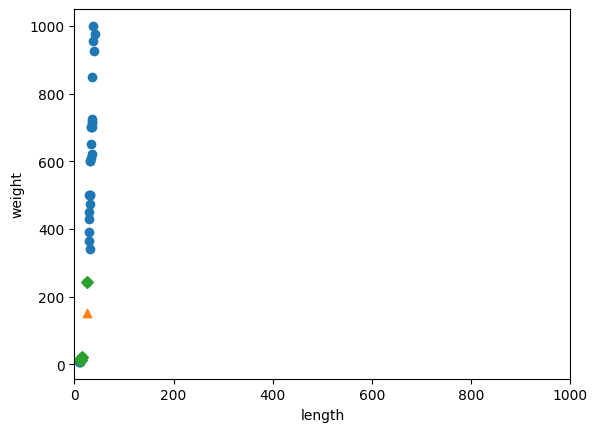

In [68]:
# 두 특성의 스케일이 달라 오류 발생
# x축이 크게 영향을 끼치지 못하도록 만들어야함

plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')
plt.xlim((0, 1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- 데이터 전처리(data preprocessing)
    - 데이터 표현 기준 다름 -> 알고리즘이 올바른 예측 불가능
        - 알고리즘이 거리 기반일 때 심함, k-최근접 이웃도 포함
    - 제대로 사용 위해 특성값을 일정한 기준으로 맞춰주는 작업 필요
    - 표준 점수(standard score, z 점수): 각 특성값이 평귱네서 표준편차의 몇 배만큼 떨어져 있는지 표현
        - 이를 통해 특성값의 크기와 상관 없이 동일한 조건으로 비교
        - $z = \frac{x - μ}{σ}$

In [69]:
# 넘파이로 평균 & 표준편차 구하기

mean = np.mean(train_input, axis=0)     # axis=0: 행을 따라 각 열의 통계 값 계산
std = np.std(train_input, axis=0)

print(mean, std)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [70]:
# 원본 데이터에서 평균 빼고 표준편차로 나누어 표준점수로 변환

train_scaled = (train_input - mean) / std

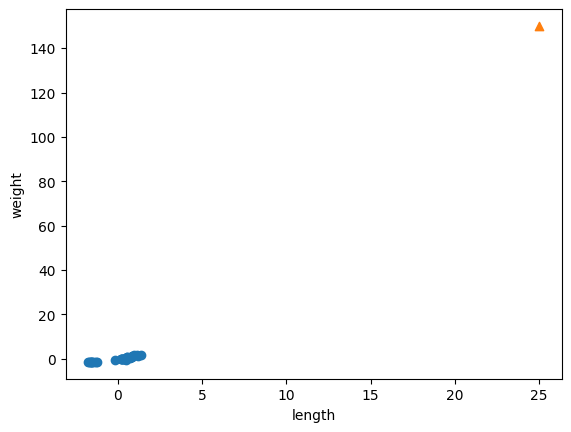

In [71]:
# 변화한 표준점수 & 샘플의 산점도

plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

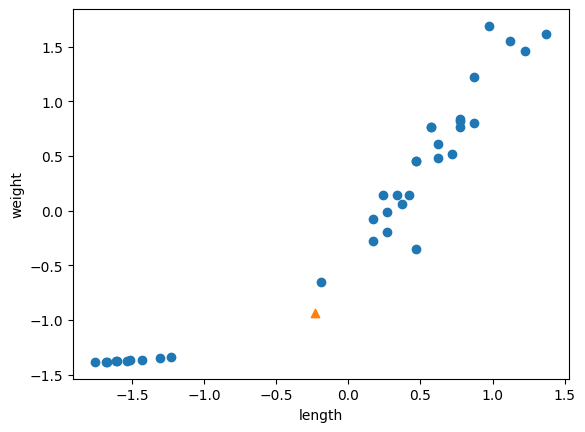

In [72]:
# 샘플 [25, 150]을 동일한 비율로 변환한 산점도

new = ([25, 150] - mean) / std
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

[1.]


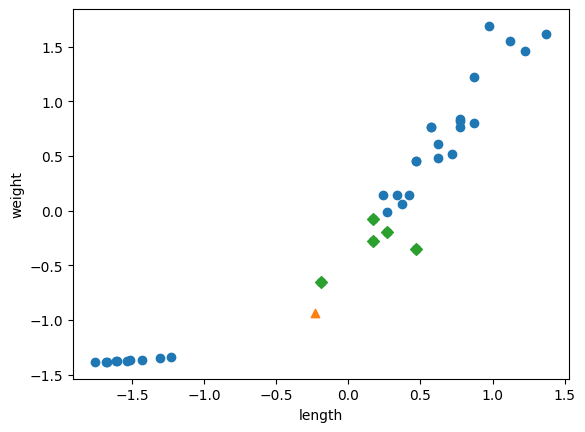

In [73]:
# 변환한 데이터셋으로 k-최근접 이웃 모델 다시 훈련
kn.fit(train_scaled, train_target)

# 테스트 세트도 훈련 세트의 평균 & 표준편차로 변환
test_scaled = (test_input - mean) / std

# 모델 평가
kn.score(test_scaled, test_target)

# 훈련 세트의 평균 & 표준편차로 변환한 new 샘플 사용해 모델의 예측 출력
print(kn.predict([new]))

# kneighbors() 함수로 이 샘플의 k-치근접 이웃 구한 다음 산점도 그리기
distances, indexes = kn.kneighbors([new])
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(new[0], new[1], marker='^')
plt.scatter(train_scaled[indexes, 0],
            train_scaled[indexes, 1], marker='D'    )
plt.xlabel('length')
plt.ylabel('weight')
plt.show()